In [1]:
# =========================================================
# 1. Imports
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Models
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor

# Display settings
sns.set_style("darkgrid", rc={"axes.facecolor": "white", "grid.color": ".8"})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

c:\Users\Cecilia\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================================
# 2. Load data
# =========================================================

# Load the feature dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic checks
print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
display(df.head(2))

Shape: (62544, 60)
Date range: 2019-01-16 00:00:00 to 2026-03-05 23:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
0,2019-01-16 00:00:00,29.23,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,22.004999,83.0,35.18,20.04,45.200000,41.705119,22.81,False,False,69793.75,10571.0,13605.00,5162.5,8970.75,3558.75,30280.00,0.0,55014.00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.450166,46.402999,27738.25,-15498.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,22876.25,-2525.75,-2456.25,9.645450,31418.75,1551.5
1,2019-01-16 01:00:00,29.26,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,22.004999,83.0,35.82,7.24,44.926667,41.836190,22.81,False,False,67991.75,11379.0,13050.75,4994.5,8959.00,3603.00,29191.25,0.0,52838.75,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.449812,46.402999,27004.25,-15541.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,21866.50,-1845.00,-835.25,10.008918,30583.50,510.5


In [3]:
# =========================================================
# 3. Define the final feature set
# =========================================================

# Define the final feature set used for modeling
# The set includes all selected usable predictors and excludes leakage-prone columns
feature_cols = [
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "hour",
    "day_of_week",
    "month",
    "temperature",
    "wind_speed",
    "is_weekend",
    "price_lag_24h",
    "price_lag_168h",
    #"price_rolling_24h",
     #"price_rolling_168h",
    "is_holiday",
    "is_hol_or_week",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "gas_price_lag_24h",
    "gas_price_lag_168h",
    "coal_price_lag_24h",
    "coal_price_lag_168h",
    "co2_price_lag_24h",
    "is_peak_hour",
    "wind_x_peak",
    "solar_x_demand",
    "renewable_share_x_peak",
    "is_crisis_period",
    "year",
    #"price_volatility_24h",
    "total_wind_forecast",
    "delta_wind_forecast",
    'residual_load',
    'load_ramp',
    'renewable_ramp'
]

In [4]:
# =========================================================
# 4. Check the selected feature set
# =========================================================

# Check whether all selected features exist in the dataframe
missing_features = [col for col in feature_cols if col not in df.columns]

# Print missing features
print("Missing features:", missing_features)

# Print number of selected features
print("Number of selected features:", len(feature_cols))

# Show the selected feature names
print(feature_cols)

# Preview the selected feature columns
display(df[feature_cols].head(2))

# Show data type counts
display(df[feature_cols].dtypes.value_counts())

# Show missing values in the selected features
display(df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

Missing features: []
Number of selected features: 36
['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'price_lag_24h', 'price_lag_168h', 'is_holiday', 'is_hol_or_week', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'is_peak_hour', 'wind_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'year', 'total_wind_forecast', 'delta_wind_forecast', 'residual_load', 'load_ramp', 'renewable_ramp']


,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,is_holiday,is_hol_or_week,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,is_peak_hour,wind_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,year,total_wind_forecast,delta_wind_forecast,residual_load,load_ramp,renewable_ramp
0,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,35.18,20.04,False,False,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.0,0.0,0.0,0.0,0.0,2019.0,31418.75,1551.5,22876.25,-2525.75,-2456.25
1,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,35.82,7.24,False,False,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.0,0.0,0.0,0.0,0.0,2019.0,30583.50,510.5,21866.50,-1845.00,-835.25


float64    33
bool        3
Name: count, dtype: int64

load                      0
wind_offshore             0
gas_price_lag_24h         0
gas_price_lag_168h        0
coal_price_lag_24h        0
coal_price_lag_168h       0
co2_price_lag_24h         0
is_peak_hour              0
wind_x_peak               0
solar_x_demand            0
renewable_share_x_peak    0
is_crisis_period          0
year                      0
total_wind_forecast       0
delta_wind_forecast       0
residual_load             0
load_ramp                 0
month_cos                 0
month_sin                 0
dow_cos                   0
dtype: int64

In [5]:
# =========================================================
# 5. Create the hourly train, validation, and test split
# =========================================================

# Create chronological masks
train_mask = df["timestamp"] < "2025-01-01"
val_mask = (df["timestamp"] >= "2025-01-01") & (df["timestamp"] < "2025-07-01")
test_mask = df["timestamp"] >= "2025-07-01"

# Create split dataframes
train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

# Show split shapes
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (52248, 60)
val_df: (4344, 60)
test_df: (5952, 60)


In [6]:
# =========================================================
# 6. Create sample weights for the training period
# =========================================================

# Create default training weights
train_weights = pd.Series(1.0, index=train_df.index)

# Assign regime-based weights
train_weights.loc[(train_df["timestamp"] >= "2019-01-01") & (train_df["timestamp"] < "2021-01-01")] = 0.6
train_weights.loc[(train_df["timestamp"] >= "2021-01-01") & (train_df["timestamp"] < "2023-01-01")] = 0.3
train_weights.loc[(train_df["timestamp"] >= "2023-01-01") & (train_df["timestamp"] < "2025-01-01")] = 1.0

# Show the weight distribution
display(train_weights.value_counts().sort_index())
display(train_weights.head())

0.3    17520
0.6    17184
1.0    17544
Name: count, dtype: int64

0    0.6
1    0.6
2    0.6
3    0.6
4    0.6
dtype: float64

In [7]:
# =========================================================
# 7. Create hourly feature matrices and targets
# =========================================================

# Create feature matrices
X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Create targets
y_train = train_df["price"].copy()
y_val = val_df["price"].copy()
y_test = test_df["price"].copy()

# Show shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (52248, 36)
X_val: (4344, 36)
X_test: (5952, 36)
y_train: (52248,)
y_val: (4344,)
y_test: (5952,)


In [8]:
# =========================================================
# 8. Build the naive hourly benchmark
# =========================================================

# Define a function for the naive hourly forecast
def predict_price_lag_hourly(df_input, price_col="price", day_col="day_of_week"):
    # Create 24-hour and 168-hour lagged prices
    lag_1 = df_input[price_col].shift(24)
    lag_7 = df_input[price_col].shift(168)

    # Use D-1 for Tue, Wed, Thu, Fri, Sun and D-7 for Mon, Sat
    lag_1_days = {1, 2, 3, 4, 6}

    # Return the naive prediction series
    return pd.Series(
        np.where(df_input[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df_input.index
    )

# Create naive hourly predictions for the full dataframe
df["price_pred_naive"] = predict_price_lag_hourly(df)

# Extract naive predictions for validation and test
y_val_naive = df.loc[val_df.index, "price_pred_naive"].copy()
y_test_naive = df.loc[test_df.index, "price_pred_naive"].copy()

In [9]:
# =========================================================
# 9. Define evaluation metrics
# =========================================================

# Define hourly MAE
def mae_hourly(y_true, y_pred):
    # Compute the mean absolute error
    return mean_absolute_error(y_true, y_pred)

# Define daily average error based on hourly predictions
def dae_hourly(y_true, y_pred, timestamps):
    # Build a temporary dataframe with timestamps, true values, and predictions
    eval_df = pd.DataFrame({
        "timestamp": timestamps,
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Aggregate to daily sums
    daily_eval = eval_df.groupby(eval_df["timestamp"].dt.floor("D")).agg({
        "y_true": "sum",
        "y_pred": "sum"
    })

    # Compute the mean daily average error
    return np.mean(np.abs(daily_eval["y_true"] - daily_eval["y_pred"]) / 24)

# Define relative MAE against the naive benchmark
def rmae(model_mae, naive_mae):
    # Compute relative MAE
    return model_mae / naive_mae

In [10]:
# =========================================================
# 10. Evaluate the naive benchmark
# =========================================================

# Compute naive validation metrics
naive_val_mae = mae_hourly(y_val, y_val_naive)
naive_val_dae = dae_hourly(y_val, y_val_naive, val_df["timestamp"])

# Compute naive test metrics
naive_test_mae = mae_hourly(y_test, y_test_naive)
naive_test_dae = dae_hourly(y_test, y_test_naive, test_df["timestamp"])

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4164
Naive validation DAE: 22.57
Naive test MAE: 23.3474
Naive test DAE: 18.8407


In [11]:
# =========================================================
# 11. Build the Lasso benchmark
# =========================================================

# Build a pipeline with feature scaling and Lasso
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

# Fit the Lasso model on the training data with sample weights
lasso_model.fit(X_train, y_train, model__sample_weight=train_weights)

# Predict on validation and test data
y_val_pred_lasso = pd.Series(lasso_model.predict(X_val), index=y_val.index)
y_test_pred_lasso = pd.Series(lasso_model.predict(X_test), index=y_test.index)

In [12]:
# =========================================================
# 12. Evaluate the Lasso benchmark
# =========================================================

# Compute Lasso validation metrics
lasso_val_mae = mae_hourly(y_val, y_val_pred_lasso)
lasso_val_dae = dae_hourly(y_val, y_val_pred_lasso, val_df["timestamp"])
lasso_val_rmae = rmae(lasso_val_mae, naive_val_mae)

# Compute Lasso test metrics
lasso_test_mae = mae_hourly(y_test, y_test_pred_lasso)
lasso_test_dae = dae_hourly(y_test, y_test_pred_lasso, test_df["timestamp"])
lasso_test_rmae = rmae(lasso_test_mae, naive_test_mae)

# Print validation results
print("Lasso validation MAE:", round(lasso_val_mae, 4))
print("Lasso validation DAE:", round(lasso_val_dae, 4))
print("Lasso validation RMAE:", round(lasso_val_rmae, 4))

# Print test results
print("Lasso test MAE:", round(lasso_test_mae, 4))
print("Lasso test DAE:", round(lasso_test_dae, 4))
print("Lasso test RMAE:", round(lasso_test_rmae, 4))

Lasso validation MAE: 16.1747
Lasso validation DAE: 11.1767
Lasso validation RMAE: 0.5692
Lasso test MAE: 14.9942
Lasso test DAE: 9.4492
Lasso test RMAE: 0.6422


In [13]:
# =========================================================
# 13. Build the final CatBoost model
# =========================================================

# Combine train and validation data for final training
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Create final sample weights for the full pre-test period
val_weights = pd.Series(1.0, index=X_val.index)
final_train_weights = pd.concat([train_weights, val_weights], axis=0)

# Build the final CatBoost model with the best local tuning parameters
catboost_model = CatBoostRegressor(
    iterations=350,
    depth=8,
    learning_rate=0.10,
    l2_leaf_reg=3,
    loss_function="MAE",
    eval_metric="MAE",
    verbose=0,
    random_state=42
)

# Fit the final CatBoost model
catboost_model.fit(
    X_final_train,
    y_final_train,
    sample_weight=final_train_weights
)

# Predict on the test set
y_test_pred_catboost = pd.Series(catboost_model.predict(X_test), index=y_test.index)

In [14]:
# =========================================================
# 14. Evaluate the final CatBoost model with the best chosen parameters
# =========================================================

# Compute CatBoost test metrics
catboost_test_mae = mae_hourly(y_test, y_test_pred_catboost)
catboost_test_dae = dae_hourly(y_test, y_test_pred_catboost, test_df["timestamp"])
catboost_test_rmae = rmae(catboost_test_mae, naive_test_mae)

# Print final CatBoost results
print("CatBoost test MAE:", round(catboost_test_mae, 4))
print("CatBoost test DAE:", round(catboost_test_dae, 4))
print("CatBoost test RMAE:", round(catboost_test_rmae, 4))

CatBoost test MAE: 11.842
CatBoost test DAE: 8.3248
CatBoost test RMAE: 0.5072


In [15]:
# =========================================================
# 15. Final comparison table
# =========================================================

# Create the final comparison table
results_final = pd.DataFrame({
    "model": ["Naive", "Lasso", "CatBoost_Final"],
    "test_MAE": [naive_test_mae, lasso_test_mae, catboost_test_mae],
    "test_DAE": [naive_test_dae, lasso_test_dae, catboost_test_dae],
    "test_RMAE": [1.0, lasso_test_rmae, catboost_test_rmae]
}).round(4)

# Display the final comparison table
display(results_final)

,model,test_MAE,test_DAE,test_RMAE
0,Naive,23.3474,18.8407,1.0000
1,Lasso,14.9942,9.4492,0.6422
2,CatBoost_Final,11.8420,8.3248,0.5072


In [16]:
# =========================================================
# 16. Build hourly evaluation dataframe
# =========================================================

# Build an hourly evaluation dataframe for the test period
eval_hourly = pd.DataFrame({
    "timestamp": test_df["timestamp"].values,
    "actual": y_test.values,
    "naive": y_test_naive.values,
    "lasso": y_test_pred_lasso.values,
    "catboost": y_test_pred_catboost.values
})

# Compute CatBoost residuals
eval_hourly["residual"] = eval_hourly["actual"] - eval_hourly["catboost"]

# Create a daily date column
eval_hourly["date"] = pd.to_datetime(eval_hourly["timestamp"]).dt.floor("D")

# Show the first rows
display(eval_hourly.head())

,timestamp,actual,naive,lasso,catboost,residual,date
0,2025-07-01 00:00:00,111.28,98.73,99.368197,93.237819,18.042181,2025-07-01
1,2025-07-01 01:00:00,95.29,89.03,87.947750,88.392156,6.897844,2025-07-01
2,2025-07-01 02:00:00,89.10,85.03,82.110559,83.057984,6.042016,2025-07-01
3,2025-07-01 03:00:00,88.08,84.13,79.944070,77.918761,10.161239,2025-07-01
4,2025-07-01 04:00:00,90.01,86.51,83.342095,83.015330,6.994670,2025-07-01


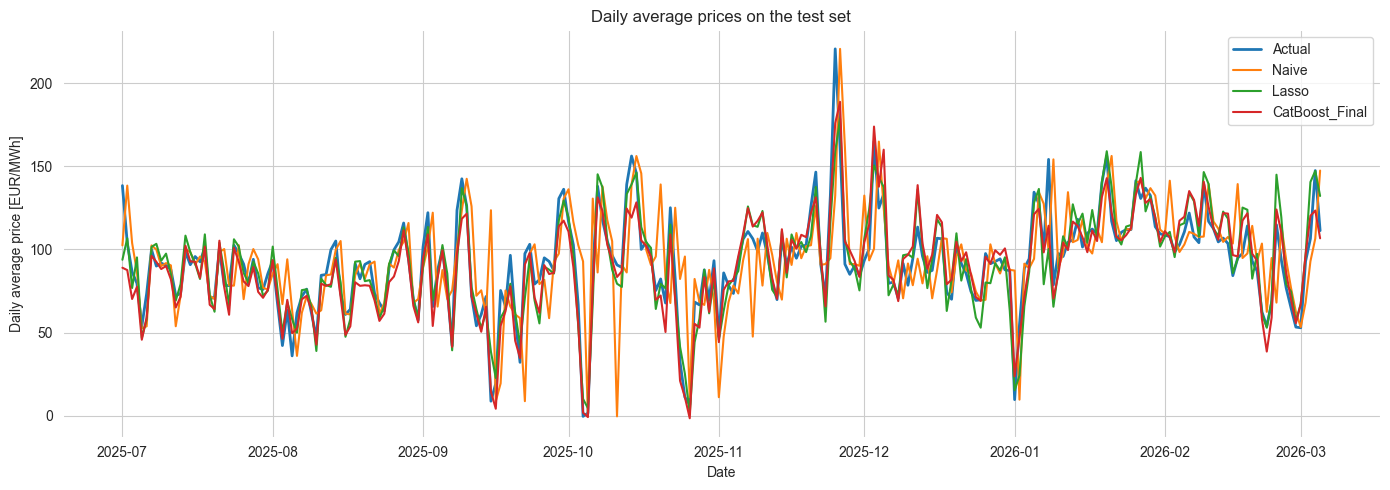

In [17]:
# =========================================================
# 17. Plot daily average prices on the test set
# =========================================================

# Aggregate hourly values to daily average values
eval_daily = eval_hourly.groupby("date")[["actual", "naive", "lasso", "catboost"]].mean().reset_index()

# Plot daily average prices
plt.figure(figsize=(14, 5))
plt.plot(eval_daily["date"], eval_daily["actual"], label="Actual", linewidth=2)
plt.plot(eval_daily["date"], eval_daily["naive"], label="Naive")
plt.plot(eval_daily["date"], eval_daily["lasso"], label="Lasso")
plt.plot(eval_daily["date"], eval_daily["catboost"], label="CatBoost_Final")
plt.xlabel("Date")
plt.ylabel("Daily average price [EUR/MWh]")
plt.title("Daily average prices on the test set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

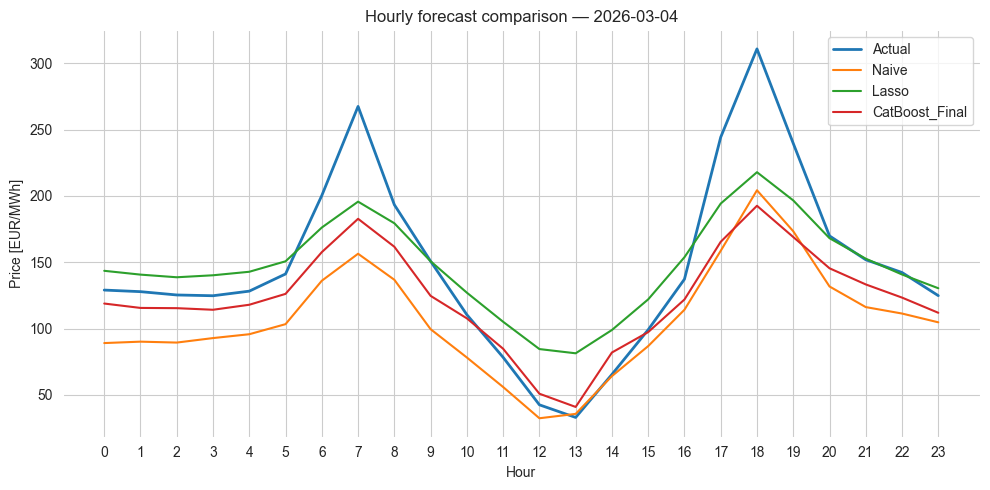

In [18]:
# =========================================================
# 18. Plot actual vs. final model for one example day
# =========================================================

# Select one test day for visual comparison
day = "2026-03-04"

# Create a mask for the selected day
day_mask = test_df["timestamp"].dt.strftime("%Y-%m-%d") == day

# Build a plotting dataframe for the selected day
plot_df = pd.DataFrame({
    "timestamp": test_df.loc[day_mask, "timestamp"].values,
    "actual": y_test.loc[day_mask].values,
    "naive": y_test_naive.loc[day_mask].values,
    "lasso": y_test_pred_lasso.loc[day_mask].values,
    "catboost": y_test_pred_catboost.loc[day_mask].values
})

# Extract the hour from the timestamp
plot_df["hour"] = pd.to_datetime(plot_df["timestamp"]).dt.hour

# Plot hourly prices for the selected day
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["lasso"], label="Lasso")
plt.plot(plot_df["hour"], plot_df["catboost"], label="CatBoost_Final")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Hourly forecast comparison — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

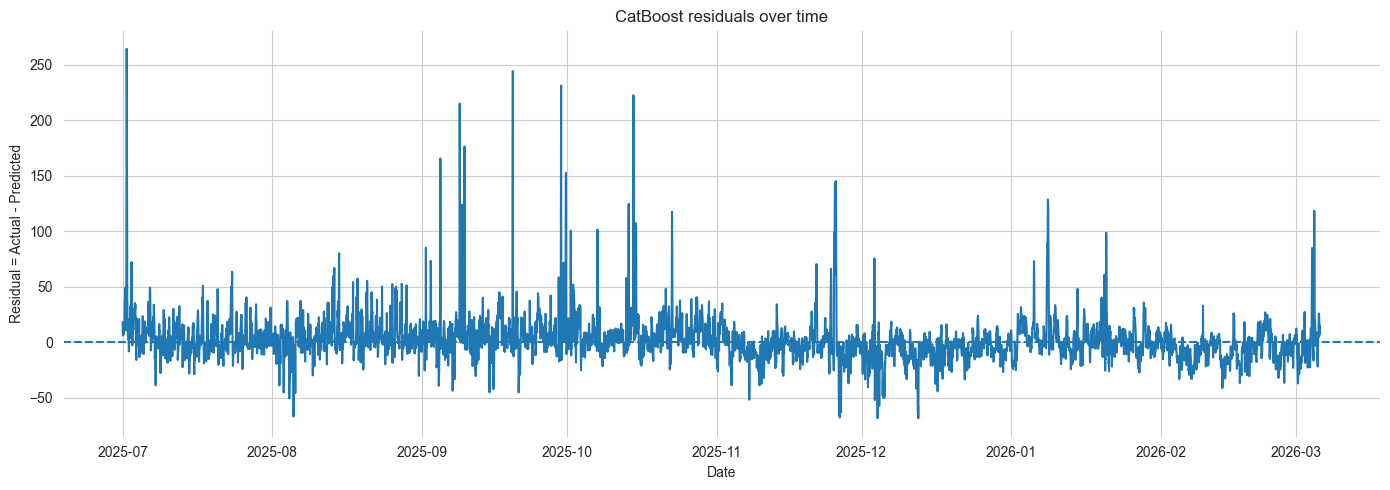

In [19]:
# =========================================================
# 19. Plot residuals over time
# =========================================================

# Plot CatBoost residuals over time
plt.figure(figsize=(14, 5))
plt.plot(eval_hourly["timestamp"], eval_hourly["residual"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Residual = Actual - Predicted")
plt.title("CatBoost residuals over time")
plt.grid(True)
plt.tight_layout()
plt.show()

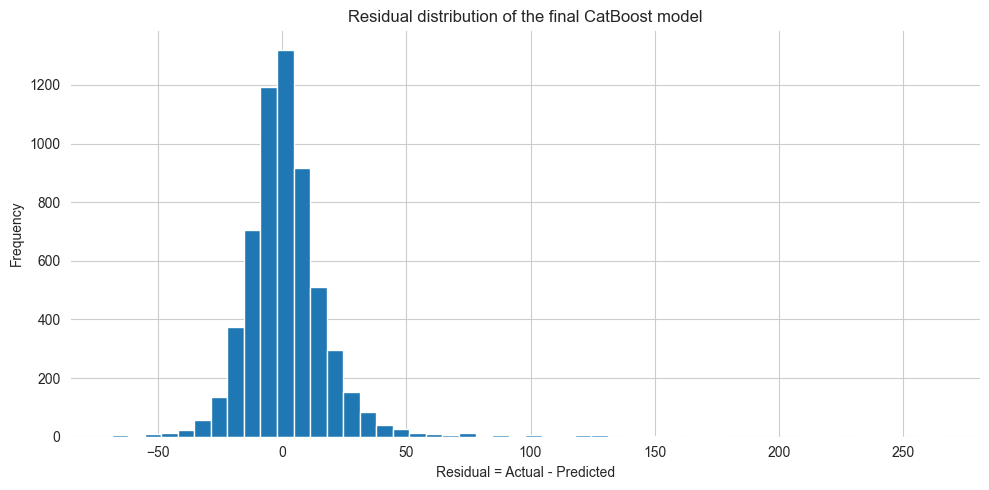

In [20]:
# =========================================================
# 20. Plot residual distribution
# =========================================================

# Plot the residual histogram
plt.figure(figsize=(10, 5))
plt.hist(eval_hourly["residual"], bins=50)
plt.xlabel("Residual = Actual - Predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution of the final CatBoost model")
plt.grid(True)
plt.tight_layout()
plt.show()

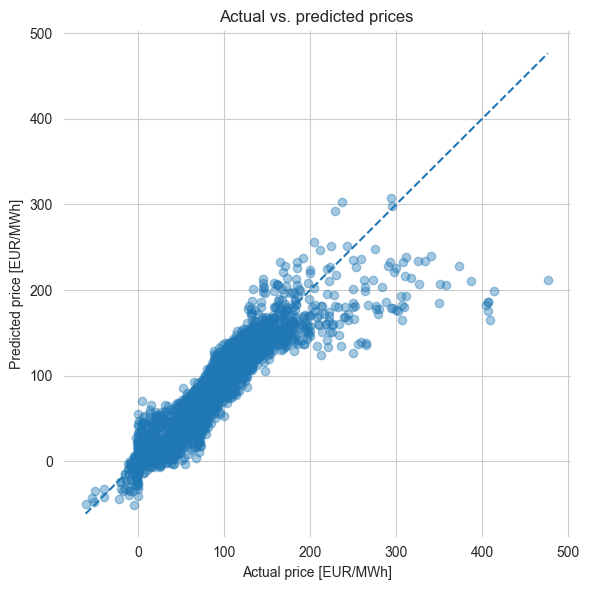

In [21]:
# =========================================================
# 21. Plot actual vs. predicted scatter
# =========================================================

# Plot actual vs predicted values
plt.figure(figsize=(6, 6))
plt.scatter(eval_hourly["actual"], eval_hourly["catboost"], alpha=0.4)

# Plot the 45-degree reference line
min_val = min(eval_hourly["actual"].min(), eval_hourly["catboost"].min())
max_val = max(eval_hourly["actual"].max(), eval_hourly["catboost"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# Add labels and title
plt.xlabel("Actual price [EUR/MWh]")
plt.ylabel("Predicted price [EUR/MWh]")
plt.title("Actual vs. predicted prices")
plt.grid(True)
plt.tight_layout()

plt.savefig("../images/residuals_scatter.png", dpi=150)  # optional: save to file

plt.show()

-----------------------------------------------------------------------------------------------------------------------------------

## SHAP Analysis

In [22]:
# CatBoost has native SHAP support — use TreeExplainer
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test)

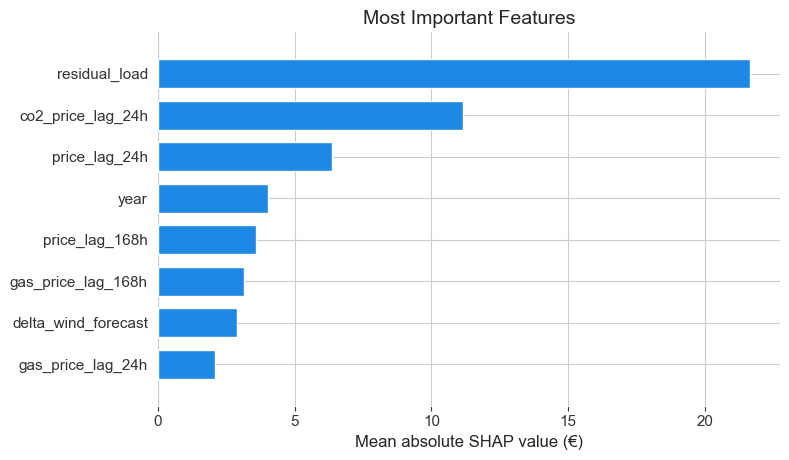

In [23]:
# Global feature importance
# Bar plot — mean absolute SHAP value per feature
#shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    color="#1E88E5",          # bar color
    max_display=8,             # show only top N features
    show=False                  # ← key: prevents auto-rendering so you can edit first
)

ax = plt.gca()



# X-axis
ax.set_xlabel("Mean absolute SHAP value (€)", fontsize=12)

# Title
ax.set_title("Most Important Features", fontsize=14)

# Tick label size
ax.tick_params(axis="both", labelsize=11)

# Remove top/right spines for cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/shap_importance.png", dpi=150)  # optional: save to file
plt.show()

In [24]:
# You can extract shap values as a data frame
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

# Table: mean absolute SHAP values
mean_importance = shap_df.abs().mean().sort_values(ascending=False)
print(mean_importance)

residual_load             21.656057
co2_price_lag_24h         11.149088
price_lag_24h              6.386109
year                       4.017259
price_lag_168h             3.603119
gas_price_lag_168h         3.154047
delta_wind_forecast        2.898136
gas_price_lag_24h          2.095765
coal_price_lag_24h         2.043770
is_crisis_period           1.979703
coal_price_lag_168h        1.926606
temperature                1.743689
solar                      1.349182
load                       1.054056
month_cos                  0.947766
solar_x_demand             0.942946
wind_x_peak                0.929450
dow_cos                    0.816263
total_wind_forecast        0.812806
month                      0.627504
is_peak_hour               0.613878
wind_offshore              0.581304
month_sin                  0.565984
renewable_ramp             0.542348
day_of_week                0.535611
hour_sin                   0.507179
hour                       0.479197
renewable_share_x_peak     0

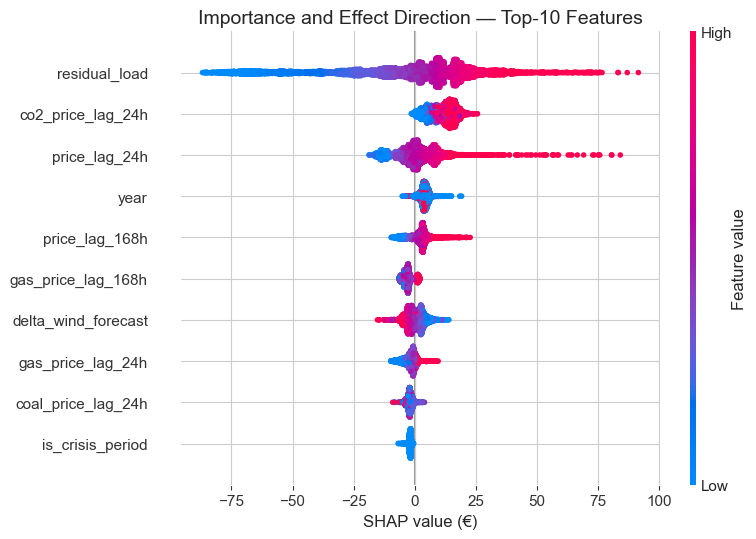

In [25]:
# Beeswarm plot — importance + effect direction
# Each dot = one sample, color = feature value (red=high, blue=low)
#shap.summary_plot(shap_values, X_test)

shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,             # show only top N features
    show=False                  # ← key: prevents auto-rendering so you can edit first
)

ax = plt.gca()

# X-axis
ax.set_xlabel("SHAP value (€)", fontsize=12)

# Title
ax.set_title("Importance and Effect Direction — Top-10 Features", fontsize=14)

# Tick label size
ax.tick_params(axis="both", labelsize=11)

# Remove top/right spines for cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/shap_beeswarm.png", dpi=150)  # optional: save to file
plt.show()

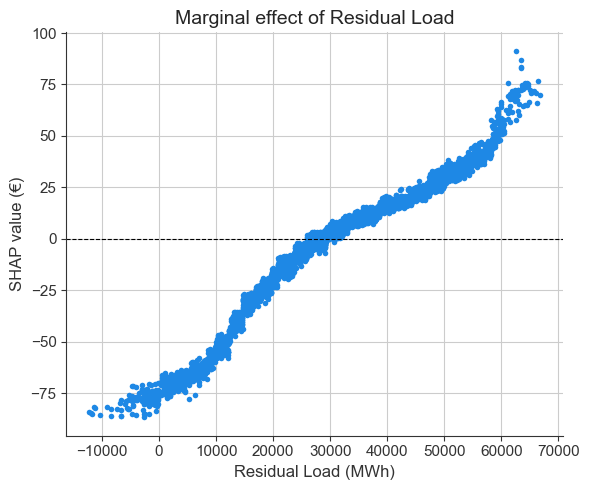

In [26]:
# Dependence plot - Residual load
shap.dependence_plot(
    "residual_load",
    shap_values,
    X_test,
    interaction_index=None,
    show=False
)

ax = plt.gca()
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")  # ← horizontal line at y=0

ax.set_xlabel("Residual Load (MWh)", fontsize=12)
ax.set_ylabel("SHAP value (€)", fontsize=12)
ax.set_title("Marginal effect of Residual Load", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

plt.savefig("../images/marginal_residload.png", dpi=150)  # optional: save to file
plt.show()

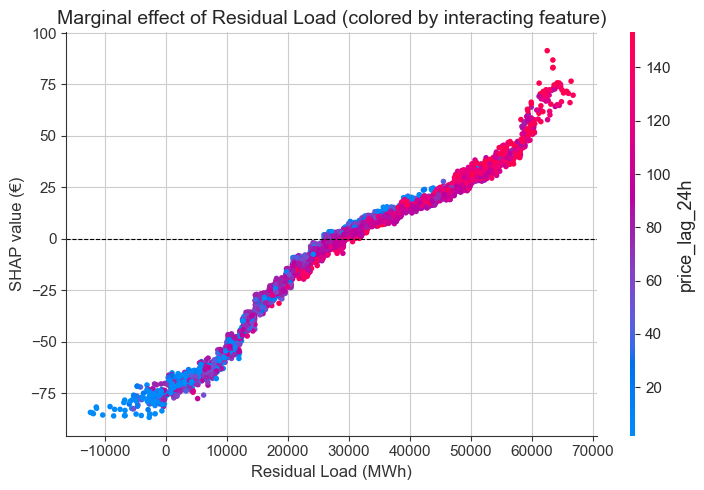

In [27]:
# Dependence plot - Residual load and Interaction effect
shap.dependence_plot(
    "residual_load",
    shap_values,
    X_test,
    show=False
)

ax = plt.gca()
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")  # ← horizontal line at y=0

ax.set_xlabel("Residual Load (MWh)", fontsize=12)
ax.set_ylabel("SHAP value (€)", fontsize=12)
ax.set_title("Marginal effect of Residual Load (colored by interacting feature)", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

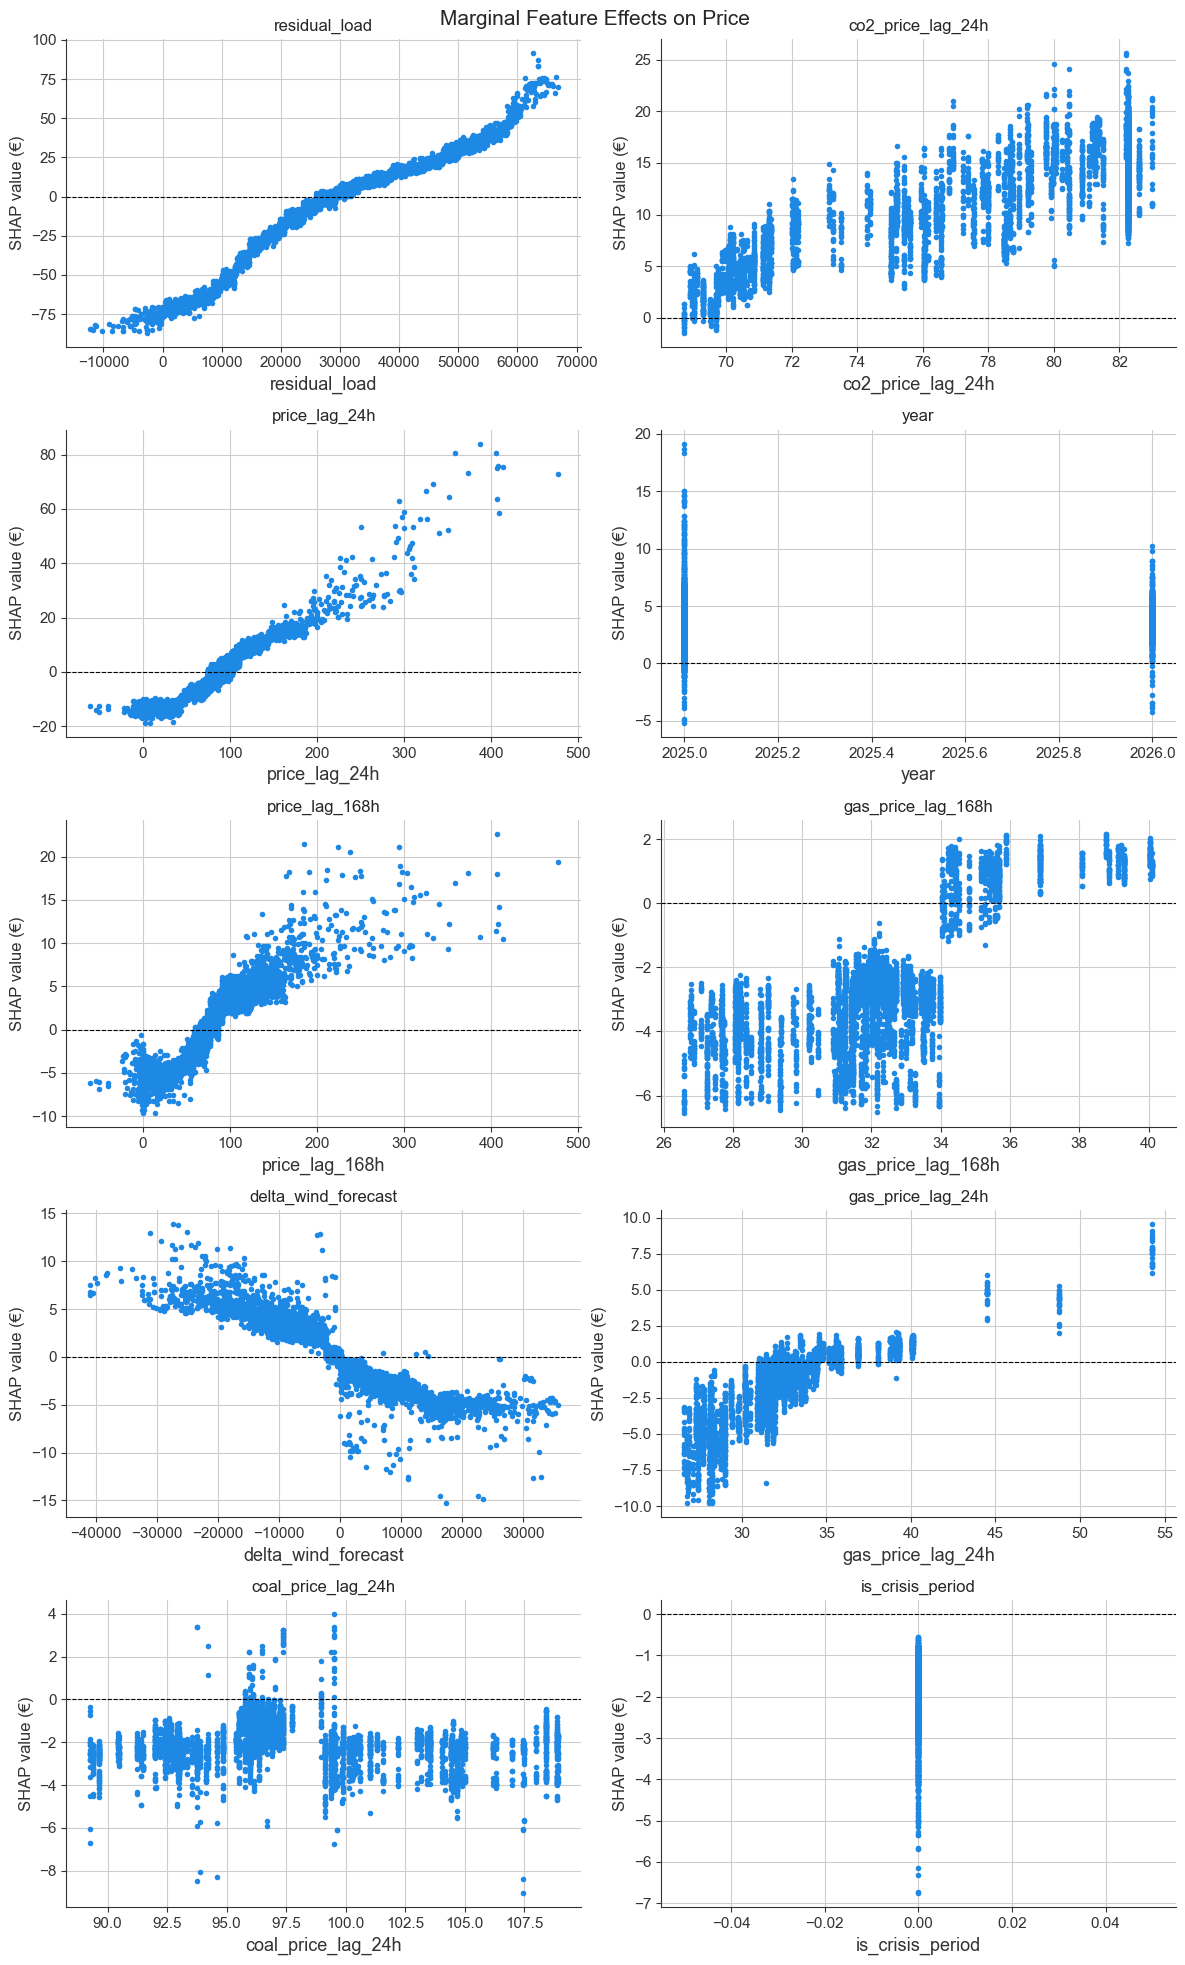

In [28]:
# Dependence plots for all top-10 features

top10 = shap_df.abs().mean().sort_values(ascending=False).head(10)
features = top10.index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()  # makes it easy to iterate

for i, feature in enumerate(features):
    shap.dependence_plot(feature, shap_values, X_test, interaction_index=None, show=False, ax=axes[i])
    axes[i].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_ylabel("SHAP value (€)", fontsize=12)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.suptitle("Marginal Feature Effects on Price", fontsize=15)
plt.tight_layout()
plt.show()

In [29]:
test_df.head(2)

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
56592,2025-07-01 00:00:00,111.28,45140.5,2201.25,11192.50,0.0,0.0,1.0,7.0,20.025002,17.297766,False,33.693001,107.449997,98.73,77.08,102.946667,72.914583,69.01,False,False,42375.25,-2099.00,13541.50,7977.25,0.0,2337.41,11106.90,56.98,45529.14,0.000000,1.000000,0.781831,0.62349,-0.5,-0.866025,32.897999,35.615002,107.5,103.349998,68.95,0.316075,63.195799,21518.75,2765.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025.0,31746.75,-1983.0,2662.75,63.162462,13393.75,1427.50
56593,2025-07-01 01:00:00,95.29,43623.0,2413.25,11830.75,0.0,1.0,1.0,7.0,18.437500,17.554737,False,33.693001,107.449997,89.03,66.79,103.207500,73.084226,69.01,False,False,40895.99,-2021.93,12564.75,7382.00,0.0,2545.53,11471.38,53.01,44302.39,0.258819,0.965926,0.781831,0.62349,-0.5,-0.866025,32.897999,35.615002,107.5,103.349998,68.95,0.348298,63.195799,19946.75,2727.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025.0,29379.00,-1517.5,850.25,63.115402,14244.00,3504.25


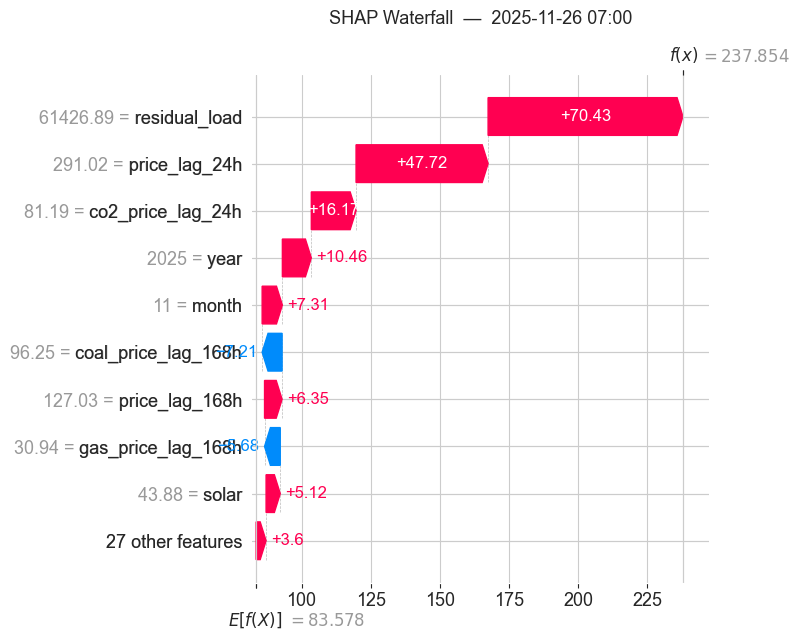

In [30]:
# Waterfall plot (one specific prediction) 
# Explain why the model predicted a specific value for one sample

# Find the position of the timestamp in test_df
idx = test_df[test_df["timestamp"] == "2025-11-26 07:00:00"].index[0]

# Use that index to locate the same row in X_test
row_position = X_test.index.get_loc(idx)

# Compute SHAP explanation object
shap_explanation = explainer(X_test)

# Plot waterfall for that specific hour
plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation[row_position], max_display=10, show=False)
plt.title("SHAP Waterfall  —  2025-11-26 07:00", fontsize=13, pad=15)
plt.tight_layout()

plt.show()

----------------------------------------------------------------------------------------------------------------------------------

## Quantile Estimation

In [31]:
# Quantile estimation with Catboost

percentiles = np.arange(0.05, 1.0, 0.05)  # predict for percentiles from 5th to 100th in steps of 5

quantile_models = {}

for q in percentiles:
    catboost_qmodel = CatBoostRegressor(
        iterations=350,
        depth=8,
        learning_rate=0.10,
        l2_leaf_reg=3,
        random_seed=42,
        loss_function=f'Quantile:alpha={q:.2f}',  # ← use q here
        verbose=0
    )
    catboost_qmodel.fit(X_final_train, y_final_train, sample_weight=final_train_weights)
    quantile_models[q] = catboost_qmodel


In [32]:
# Predict on test set
predictions = {q: model.predict(X_test) for q, model in quantile_models.items()}

forecast_df = pd.DataFrame(predictions)
forecast_df.columns = [f"Q{int(round(q*100))}" for q in percentiles]

In [33]:
# Check that predictions are different across quantiles
print(forecast_df.head())
print(forecast_df.describe())

          Q5        Q10        Q15        Q20        Q25        Q30        Q35        Q40        Q45        Q50        Q55        Q60   
0  83.130969  87.423636  87.311914  88.757188  87.680294  90.346728  90.180036  88.003331  93.761125  93.237819  95.541656  95.092421  \
1  77.798972  80.541027  83.391169  82.550458  79.193966  77.999436  84.799794  77.351813  85.426815  88.392156  89.854803  89.337698   
2  69.695586  69.603668  70.238468  77.195190  74.869978  74.640495  79.793743  75.863620  78.131313  83.057984  84.098868  82.745076   
3  68.553336  68.081566  69.671942  75.708322  72.385290  73.678185  75.760332  74.705371  75.301735  77.918761  80.586268  78.747864   
4  74.978243  72.477244  77.913509  79.115537  74.176750  75.100431  79.024245  75.669225  82.039762  83.015330  84.166039  84.763322   

         Q65        Q70        Q75        Q80        Q85         Q90         Q95  
0  95.221309  94.534551  96.421481  97.164272  99.753700  107.128663  103.219236  
1  88.92777

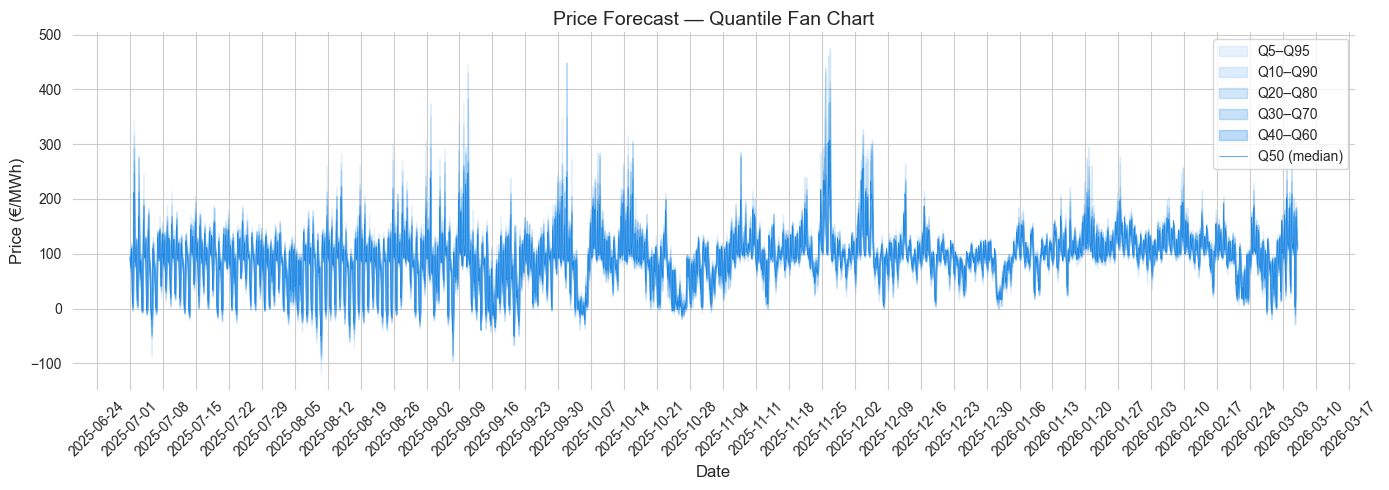

In [34]:
import matplotlib.dates as mdates

# Attach timestamps from test_df
forecast_df.index = test_df["timestamp"].values

fig, ax = plt.subplots(figsize=(14, 5))

# Define quantile pairs for shading (symmetric around median)
bands = [
    ("Q5",  "Q95", 0.10),
    ("Q10", "Q90", 0.15),
    ("Q20", "Q80", 0.20),
    ("Q30", "Q70", 0.25),
    ("Q40", "Q60", 0.30),
]

for lower, upper, alpha in bands:
    ax.fill_between(
        forecast_df.index,
        forecast_df[lower],
        forecast_df[upper],
        alpha=alpha,
        color="#1E88E5",
        label=f"{lower}–{upper}"
    )

# Median line
ax.plot(forecast_df.index, forecast_df["Q50"], color="#1E88E5", linewidth=0.5, label="Q50 (median)")

# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (€/MWh)", fontsize=12)
ax.set_title("Price Forecast — Quantile Fan Chart", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

The issue of "quantile crossing" is visible. For example, the median forecast can fall outside the 25-75 color band. Quantile crossing happens because quantile estimations are done independently from each other.

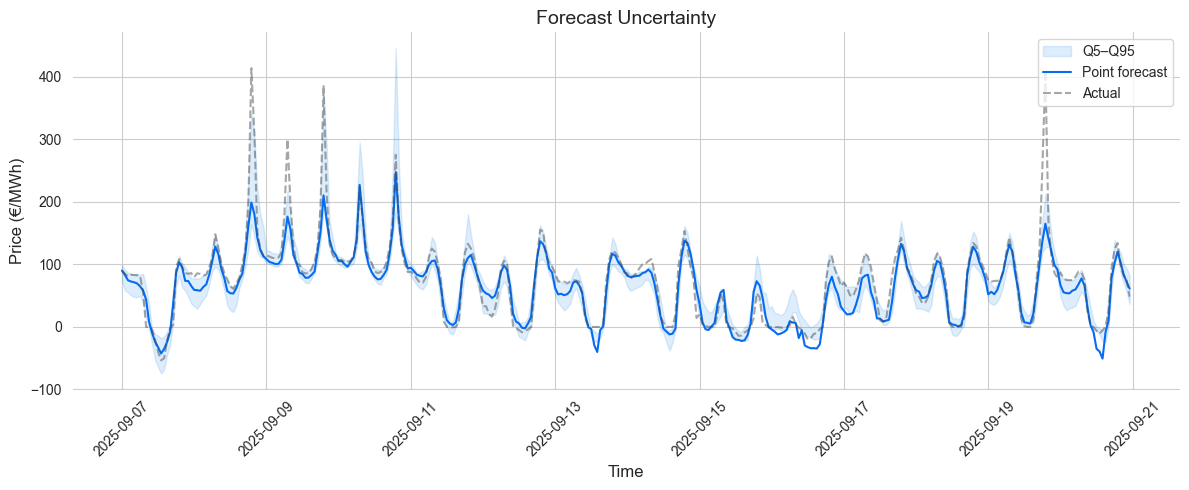

In [35]:
# Zoom in on a shorter period

# Attach timestamps to forecast_df
forecast_df.index = test_df["timestamp"]

# Add both y_test and y_pred into forecast_df so everything shares the same index
forecast_df["y_actual"] = y_test.values
forecast_df["y_pred"] = y_test_pred_catboost.values

# Filter the period
mask = (forecast_df.index >= "2025-09-07 00:00") & (forecast_df.index <= "2025-09-20 23:00")
plot_df = forecast_df[mask]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

# Quantile bands
ax.fill_between(plot_df.index, plot_df["Q5"], plot_df["Q95"], alpha=0.15, color="#1E88E5", label="Q5–Q95")

# Mean forecast
ax.plot(plot_df.index, plot_df["y_pred"], color="#056CF2", linewidth=1.5, label="Point forecast")

# Actuals
ax.plot(plot_df.index, plot_df["y_actual"], color="#44494B7C", linewidth=1.5, linestyle="--", label="Actual")

ax.set_title("Forecast Uncertainty", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Price (€/MWh)", fontsize=12)
ax.legend(loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/fcast_uncertainty.png", dpi=150)  # optional: save to file
plt.show()